In [42]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import sklearn.metrics

import ARA_model

In [43]:
def import_predictions(prediction_files: dict, predictions_base_path: str = "predictions/") -> pd.DataFrame:
    data_frames = []
    sentence_column = None

    for file_name, file_path in prediction_files.items():

        file_path = predictions_base_path + file_path

        new_data = ARA_model.import_jsonl(file_path, row_key="id")

        new_df = pd.DataFrame.from_dict(new_data, orient="index")
        new_df = new_df.rename(columns={"prediction": file_name})

        # Store the sentence column from the first file
        if sentence_column is None and "sentence" in new_df.columns:
            sentence_column = new_df[["sentence"]]

        data_frames.append(new_df[[file_name, "label"]])
    
    # Merge all dataframes
    merged_df = data_frames[0]
    for new_df in data_frames[1:]:
        merged_df = merged_df.merge(new_df.drop(columns=["label"]), left_index=True, right_index=True, how="inner")

    # Add the sentence column
    if sentence_column is not None:
        merged_df = merged_df.merge(sentence_column, left_index=True, right_index=True, how="left")

    return merged_df

In [44]:
# Import the models

train_predictions = {
                    "Sentence_Length": "ARA_Baseline_train.jsonl",
                    "Readability_Formula": "ARA_RF_model_train.jsonl",
                    "LLM": "ARA_LLM_model_train.jsonl",
                    "Syntax": "ARA_Syntax_model_train.jsonl",
                    "Transformer": "ARA_Transformer_model_train.jsonl"
                }

dev_predictions = {
                    "Sentence_Length": "ARA_Baseline_dev.jsonl",
                    "Readability_Formula": "ARA_RF_model_dev.jsonl",
                    "LLM": "ARA_LLM_model_dev.jsonl",
                    "Syntax": "ARA_Syntax_model_dev.jsonl",
                    "Transformer": "ARA_Transformer_model_dev.jsonl"
                }

eval_predictions = {
                    "Sentence_Length": "ARA_Baseline_eval.jsonl",
                    "Readability_Formula": "ARA_RF_model_eval.jsonl",
                    "LLM": "ARA_LLM_model_eval.jsonl",
                    "Syntax": "ARA_Syntax_model_eval.jsonl",
                    "Transformer": "ARA_Transformer_model_eval.jsonl"
                }


all_train_df = import_predictions(train_predictions, predictions_base_path="predictions/")
all_dev_df = import_predictions(dev_predictions, predictions_base_path="predictions/")
all_eval_df = import_predictions(eval_predictions, predictions_base_path="predictions/")

print(len(all_train_df))
print(len(all_dev_df))
print(len(all_eval_df))

2780
267
407


Readability_Formula train preds


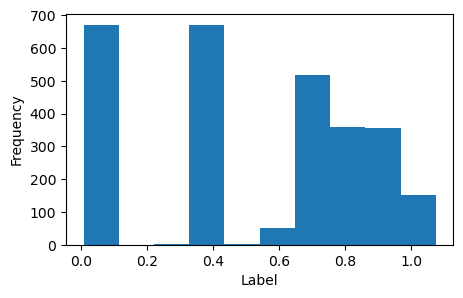

LLM train preds


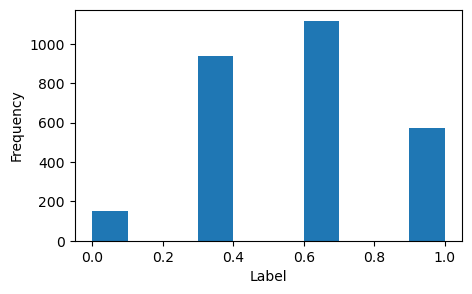

Syntax train preds


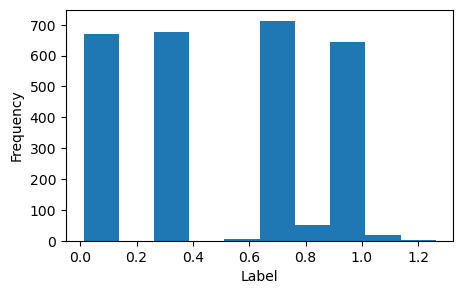

Transformer train preds


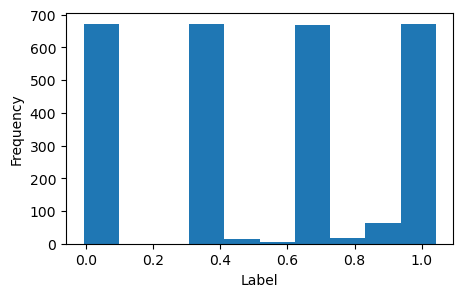

In [45]:
print("Readability_Formula train preds")
plt.figure(figsize=(5, 3))
plt.hist(all_train_df['Readability_Formula'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("LLM train preds")
plt.figure(figsize=(5, 3))
plt.hist(all_train_df['LLM'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("Syntax train preds")
plt.figure(figsize=(5, 3))
plt.hist(all_train_df['Syntax'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("Transformer train preds")
plt.figure(figsize=(5, 3))
plt.hist(all_train_df['Transformer'])
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

Readability_Formula dev preds


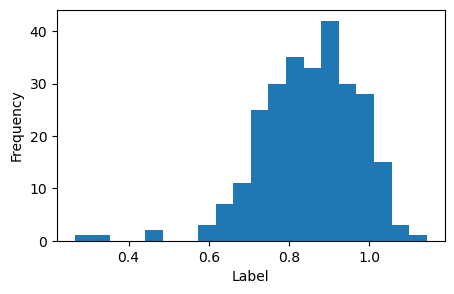

LLM dev preds


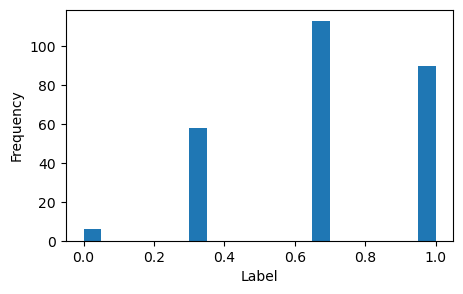

Syntax dev preds


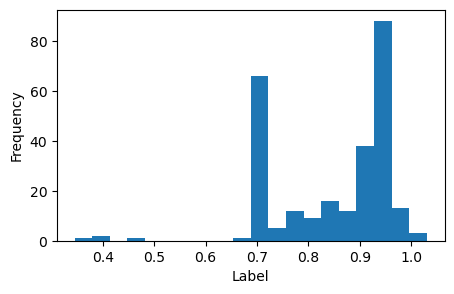

Transformer dev preds


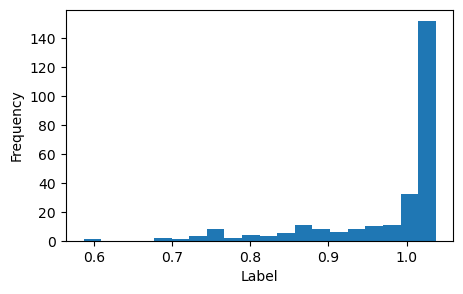

In [46]:
print("Readability_Formula dev preds")
plt.figure(figsize=(5, 3))
plt.hist(all_dev_df['Readability_Formula'], bins=20)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("LLM dev preds")
plt.figure(figsize=(5, 3))
plt.hist(all_dev_df['LLM'], bins=20)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("Syntax dev preds")
plt.figure(figsize=(5, 3))
plt.hist(all_dev_df['Syntax'], bins=20)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

print("Transformer dev preds")
plt.figure(figsize=(5, 3))
plt.hist(all_dev_df['Transformer'], bins=20)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

Readability_Formula eval preds


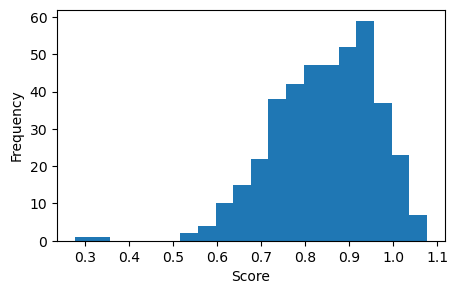

LLM-based eval preds


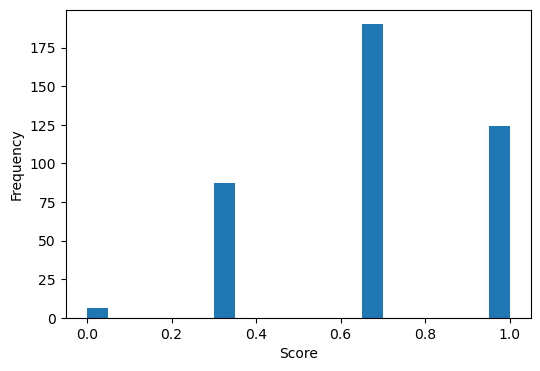

Syntax-based eval preds


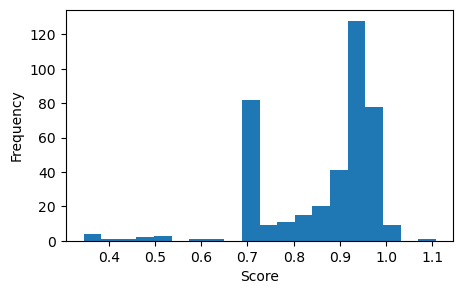

Transformer-based eval preds


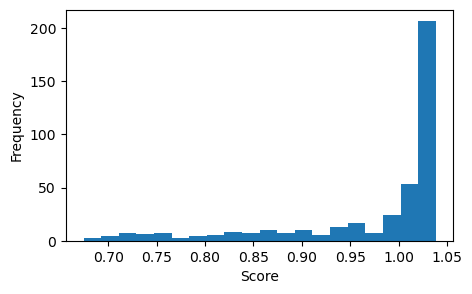

In [47]:
print("Readability_Formula eval preds")
plt.figure(figsize=(5, 3))
plt.hist(all_eval_df['Readability_Formula'], bins=20)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

print("LLM-based eval preds")
plt.figure(figsize=(6, 4))
plt.hist(all_eval_df['LLM'], bins=20)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

print("Syntax-based eval preds")
plt.figure(figsize=(5, 3))
plt.hist(all_eval_df['Syntax'], bins=20)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

print("Transformer-based eval preds")
plt.figure(figsize=(5, 3))
plt.hist(all_eval_df['Transformer'], bins=20)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

# Analyzing the Labels in the Dataset

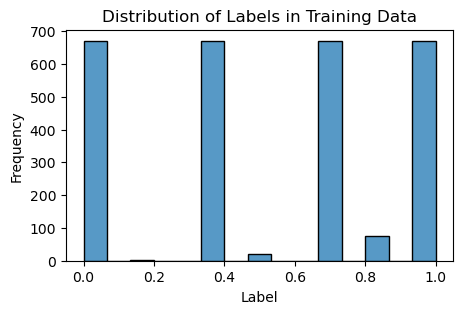

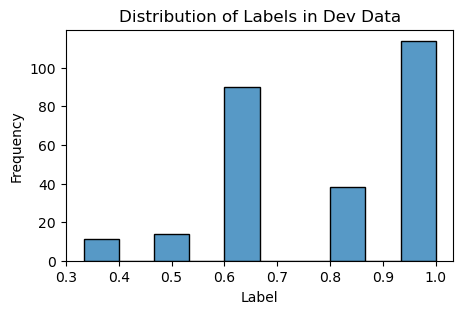

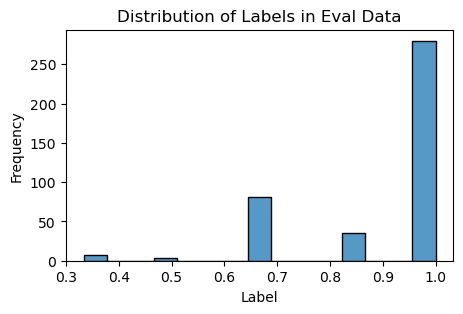

In [48]:
plt.figure(figsize=(5, 3))
sns.histplot(all_train_df['label'])
plt.title('Distribution of Labels in Training Data')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(5, 3))
sns.histplot(all_dev_df['label'])
plt.title('Distribution of Labels in Dev Data')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(5, 3))
sns.histplot(all_eval_df['label'])
plt.title('Distribution of Labels in Eval Data')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

# Analyzing the Predictions of the Models

## Analyzing the whole data splits

In [49]:
def calculate_scores(predictions: dict):

    scores = defaultdict()
    for model_name in predictions.keys():
        if model_name == "label" or model_name == "sentence":
            continue

        mae = sklearn.metrics.mean_absolute_error(predictions["label"], predictions[model_name])
        mse = sklearn.metrics.mean_squared_error(predictions["label"], predictions[model_name])
        rmse = np.sqrt(mse)
        scores[model_name] = {
            "MSE": np.round(mse, 4),
            "MAE": np.round(mae, 4),
            "RMSE": np.round(rmse, 4)
        }

    return scores

In [50]:
# Calculate scores for each model
all_train_scores = calculate_scores(all_train_df)
for model_name in all_train_scores.keys():
    print(f"Train {model_name} - MSE: {all_train_scores[model_name]['MSE']}, MAE: {all_train_scores[model_name]['MAE']}, RMSE: {all_train_scores[model_name]['RMSE']}")

print()

all_dev_scores = calculate_scores(all_dev_df)
for model_name in all_dev_scores.keys():
    print(f"Dev {model_name} - MSE: {all_dev_scores[model_name]['MSE']}, MAE: {all_dev_scores[model_name]['MAE']}, RMSE: {all_dev_scores[model_name]['RMSE']}")

print()

all_eval_scores = calculate_scores(all_eval_df)
for model_name in all_eval_scores.keys():
    print(f"Eval {model_name} - MSE: {all_eval_scores[model_name]['MSE']}, MAE: {all_eval_scores[model_name]['MAE']}, RMSE: {all_eval_scores[model_name]['RMSE']}")

Train Sentence_Length - MSE: 0.135, MAE: 0.3238, RMSE: 0.3674
Train Readability_Formula - MSE: 0.0064, MAE: 0.0535, RMSE: 0.0803
Train LLM - MSE: 0.1583, MAE: 0.2939, RMSE: 0.3978
Train Syntax - MSE: 0.0032, MAE: 0.0395, RMSE: 0.057
Train Transformer - MSE: 0.0007, MAE: 0.0219, RMSE: 0.026

Dev Sentence_Length - MSE: 0.1331, MAE: 0.3187, RMSE: 0.3649
Dev Readability_Formula - MSE: 0.0502, MAE: 0.1783, RMSE: 0.224
Dev LLM - MSE: 0.0853, MAE: 0.2085, RMSE: 0.2921
Dev Syntax - MSE: 0.0483, MAE: 0.1749, RMSE: 0.2197
Dev Transformer - MSE: 0.0602, MAE: 0.181, RMSE: 0.2453

Eval Sentence_Length - MSE: 0.1859, MAE: 0.4017, RMSE: 0.4312
Eval Readability_Formula - MSE: 0.0394, MAE: 0.1588, RMSE: 0.1984
Eval LLM - MSE: 0.1119, MAE: 0.2469, RMSE: 0.3345
Eval Syntax - MSE: 0.0389, MAE: 0.1502, RMSE: 0.1971
Eval Transformer - MSE: 0.0295, MAE: 0.1114, RMSE: 0.1716


In [51]:
def plot_scores(scores: dict, title: str, metric = "MAE", save = True):

    # matplotlib.use('Agg')

    plt.figure(figsize=(5, 3))
    sns.barplot(x=list(scores.keys()), y=[scores[model][metric] for model in scores.keys()])
    plt.title(f'{title} ({metric})')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()

    if metric == "MAE":
        plt.ylim(0, 0.5)
    elif metric == "MSE":
        plt.ylim(0, 0.3)
    else:
        pass

    # Add individual values to the bars
    for i, model in enumerate(scores.keys()):
        value = scores[model][metric]
        plt.text(i, value, f"{value:.3f}", ha='center', va='bottom', fontsize=8)

    if save:
        plt.savefig(f"plots/{title}.png")
    else:
        plt.show()

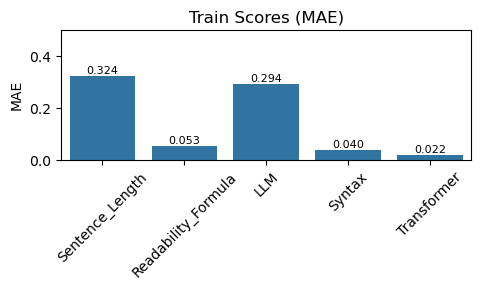

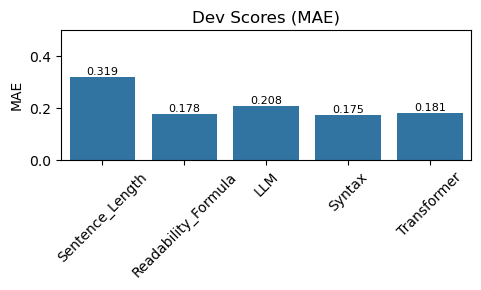

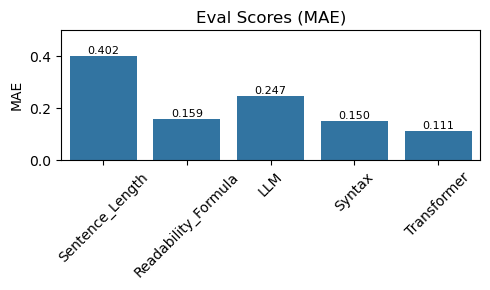

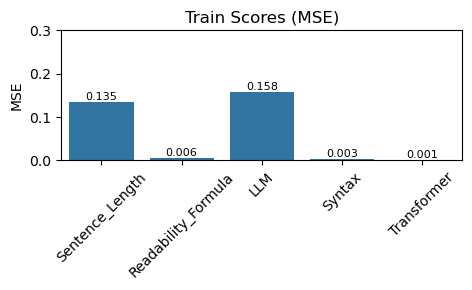

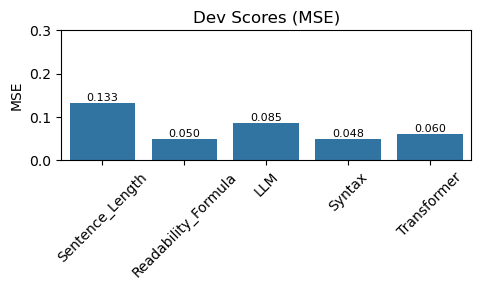

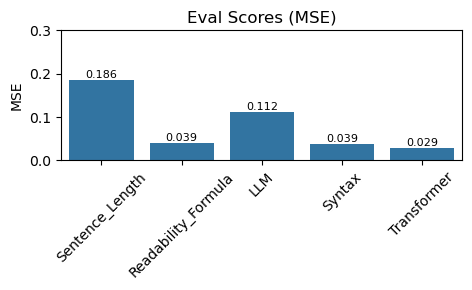

In [52]:
plot_scores(all_train_scores, "Train Scores", metric="MAE", save=False)
plot_scores(all_dev_scores, "Dev Scores", metric="MAE", save=False)
plot_scores(all_eval_scores, "Eval Scores", metric="MAE", save=False)

plot_scores(all_train_scores, "Train Scores", metric="MSE", save=False)
plot_scores(all_dev_scores, "Dev Scores", metric="MSE", save=False)
plot_scores(all_eval_scores, "Eval Scores", metric="MSE", save=False)

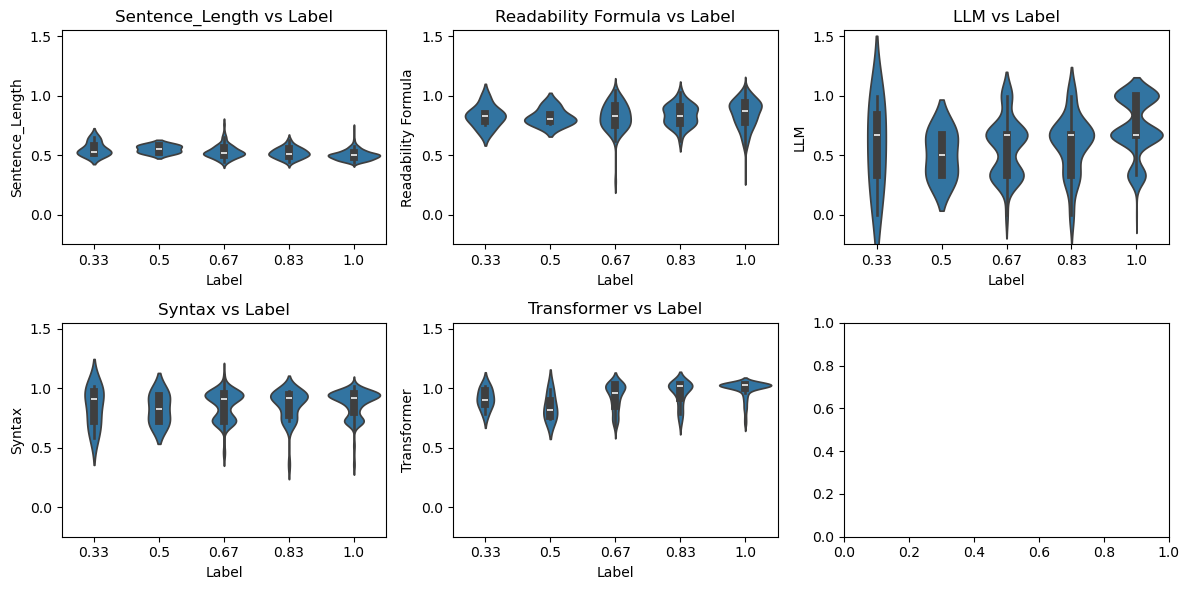

In [53]:
def grouped_violin_plots(df: pd.DataFrame, filename="violin_plots.pdf"):
    """
    Create violin plots for each feature in the dataframe against the ground truth labels.
    The plots are arranged in two rows with three subplots each.
    """
    df = df.round(2)

    features = df.drop(['label', 'sentence'], axis=1).columns

    # Create a figure with subplots (2 rows, 3 columns)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    # Plot each model's predictions against the ground truth
    for i, feature in enumerate(features):
        sns.violinplot(x='label', y=feature, data=df, ax=axes[i])
        axes[i].set_ylim(-0.25, 1.55)
        # Renaming for better readability
        if feature == "Readability_Formula":
            feature = "Readability Formula"
        elif feature == "Mixture_of_Experts":
            feature = "Mixture of Experts"
        axes[i].set_title(f'{feature} vs Label')
        axes[i].set_xlabel('Label')
        axes[i].set_ylabel(feature)


    plt.tight_layout()
    plt.show()
    # fig.savefig(filename, format="pdf")

grouped_violin_plots(all_eval_df, "figures/eval_violin_plots.pdf")

### Kendall Tau Scores

In [54]:
def kendalltau_scores(df: pd.DataFrame):
    """
    Calculate Kendall's tau correlation scores for each model's predictions against the ground truth labels.
    """
    results = {}
    for column in df.columns:
        if column != 'label' and column != 'sentence':
            tau, p_value = scipy.stats.kendalltau(df[column], df['label'], variant='b')
            results[column] = (tau, p_value)

    print("Kendall's Tau Scores:")
    for model, (tau, p_value) in results.items():
        print(f"{model}: tau = {tau:.4f}, p-value = {p_value:.4f}")
    return results
print("Kendall Tau (b) scores")
print("Train") 
kendalltau_scores(all_train_df)
print("\nDev")
kendalltau_scores(all_dev_df)
print("\nEval")
kendalltau_scores(all_eval_df)
print()

Kendall Tau (b) scores
Train
Kendall's Tau Scores:
Sentence_Length: tau = 0.0681, p-value = 0.0000
Readability_Formula: tau = 0.8547, p-value = 0.0000
LLM: tau = 0.2529, p-value = 0.0000
Syntax: tau = 0.9190, p-value = 0.0000
Transformer: tau = 0.8820, p-value = 0.0000

Dev
Kendall's Tau Scores:
Sentence_Length: tau = -0.1458, p-value = 0.0022
Readability_Formula: tau = 0.0581, p-value = 0.2128
LLM: tau = 0.3162, p-value = 0.0000
Syntax: tau = 0.0555, p-value = 0.2446
Transformer: tau = 0.2371, p-value = 0.0000

Eval
Kendall's Tau Scores:
Sentence_Length: tau = -0.2290, p-value = 0.0000
Readability_Formula: tau = 0.0863, p-value = 0.0271
LLM: tau = 0.2822, p-value = 0.0000
Syntax: tau = 0.0534, p-value = 0.1780
Transformer: tau = 0.2461, p-value = 0.0000



In [55]:
def round_to_nearest_half(x):
    return round(x * 2) / 2

In [56]:
def rounded_kendalltau_scores(input: pd.DataFrame):

    df = input.copy()

    results = {}
    for column in df.columns:
        if column != 'label' and column != 'sentence':

            predictions = df[column].apply(round_to_nearest_half)
            labels = df['label'].apply(round_to_nearest_half)

            tau, p_value = scipy.stats.kendalltau(predictions, labels, variant='b')
            results[column] = (tau, p_value)

    print("Rounded Kendall's Tau Scores:")
    for model, (tau, p_value) in results.items():
        print(f"{model}: tau = {tau:.4f}, p-value = {p_value:.4f}")
    return results

print("Train")
rounded_kendalltau_scores(all_train_df)
print("\nDev")
rounded_kendalltau_scores(all_dev_df)
print("\nEval")
rounded_kendalltau_scores(all_eval_df)

Train
Rounded Kendall's Tau Scores:
Sentence_Length: tau = 0.0350, p-value = 0.0519
Readability_Formula: tau = 0.9095, p-value = 0.0000
LLM: tau = 0.2622, p-value = 0.0000
Syntax: tau = 0.9705, p-value = 0.0000
Transformer: tau = 0.9996, p-value = 0.0000

Dev
Rounded Kendall's Tau Scores:
Sentence_Length: tau = 0.0756, p-value = 0.2178
Readability_Formula: tau = 0.1161, p-value = 0.0583
LLM: tau = 0.2535, p-value = 0.0000
Syntax: tau = 0.0380, p-value = 0.5356
Transformer: tau = 0.1133, p-value = 0.0646

Eval
Rounded Kendall's Tau Scores:
Sentence_Length: tau = -0.0918, p-value = 0.0643
Readability_Formula: tau = 0.0437, p-value = 0.3783
LLM: tau = 0.2112, p-value = 0.0000
Syntax: tau = 0.1180, p-value = 0.0174
Transformer: tau = 0.1730, p-value = 0.0005


{'Sentence_Length': (-0.09183290999593141, 0.06425853103298261),
 'Readability_Formula': (0.0437220357904841, 0.37833156236275),
 'LLM': (0.21120625815372074, 1.8248467305093058e-05),
 'Syntax': (0.11804326739232544, 0.017382957233540948),
 'Transformer': (0.1730164373423584, 0.0004899627463143145)}

### Average Predictions by the models

In [57]:
def average_predictions(df: pd.DataFrame):
    """
    Average prediction of the whole datasplit for each model.
    """
    models = [col for col in df.columns if col not in ['sentence']]

    # filter out oversampling ("oversampled" in id)
    cleaned_df = df[~df.index.str.contains("OVERSAMPLED")]
    
    print(f"Number of samples before filtering: {len(df)}")
    print(f"Number of samples after filtering: {len(cleaned_df)}")



    average_pred = {model: (cleaned_df[model].mean() * 3 + 1).round(3) for model in models}
    
    return average_pred

print("Train:", average_predictions(all_train_df))
print("Dev:", average_predictions(all_dev_df))
print("Eval:", average_predictions(all_eval_df))

Number of samples before filtering: 2780
Number of samples after filtering: 960
Train: {'Sentence_Length': 2.523, 'label': 3.695, 'Readability_Formula': 3.527, 'LLM': 3.077, 'Syntax': 3.608, 'Transformer': 3.79}
Number of samples before filtering: 267
Number of samples after filtering: 267
Dev: {'Sentence_Length': 2.535, 'label': 3.431, 'Readability_Formula': 3.551, 'LLM': 3.075, 'Syntax': 3.555, 'Transformer': 3.933}
Number of samples before filtering: 407
Number of samples after filtering: 407
Eval: {'Sentence_Length': 2.531, 'label': 3.709, 'Readability_Formula': 3.528, 'LLM': 3.061, 'Syntax': 3.596, 'Transformer': 3.92}


## Comparing the models MSE based on the ground truth labels

In [58]:
def mse_per_ground_truth(df: pd.DataFrame):
    """
    Calculate the Mean Squared Error (MSE) of predictions for each model, grouped by ground truth labels.
    """
    mse_results = defaultdict(dict)
    models = [col for col in df.columns if col not in ['label', 'sentence']]
    
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label]
        for model in models:
            mse_results[model][label] = sklearn.metrics.mean_squared_error(subset['label'], subset[model])
    
    mse_df = pd.DataFrame(mse_results).T

    mse_df = mse_df.round(4)
    return mse_df

In [59]:
# Evaluation datasplit
analysis_mse_per_ground_truth_eval = mse_per_ground_truth(all_eval_df)

analysis_mse_per_ground_truth_eval.to_csv("results/ARA/mse_per_ground_truth_eval.csv")

analysis_mse_per_ground_truth_eval

,0.333333,0.500000,0.666667,0.833333,1.000000
Sentence_Length,0.0509,0.0036,0.0215,0.1000,0.2502
Readability_Formula,0.2511,0.1081,0.0387,0.0081,0.0372
LLM,0.1746,0.0278,0.0672,0.1167,0.1238
Syntax,0.2783,0.1179,0.0506,0.0166,0.0311
Transformer,0.3431,0.1270,0.0806,0.0258,0.0059


# ARA Syntax Model Ablation Study

In [60]:
syntax_full_eval = pd.read_csv("results/ARA/Syntax_model_eval.csv", index_col=0)
syntax_full_eval = syntax_full_eval.iloc[-1]
syntax_full_eval = syntax_full_eval.rename("No ablated feature")

In [61]:
# Ablation study results
syntax_ablation_eval = pd.read_csv("results/ARA/Syntax_model_ablation_study_eval.csv", index_col=0)

# Subtract the full model
syntax_eval_changes = syntax_ablation_eval - syntax_full_eval
syntax_eval_changes = pd.DataFrame.round(syntax_eval_changes, 4)

syntax_eval_changes.to_csv("results/ARA/Syntax_model_ablation_study_eval_changes.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'results/ARA/Syntax_model_ablation_study_eval.csv'